# Who Wins the 2026 World Cup? A Knockout-Stage Forecasting Model

**Goal:** predict the outcome of the remaining 2026 FIFA World Cup knockout matches
(Quarterfinals → Final) using a model trained on 2006–2022 World Cup history.

**Why this is harder than it sounds:** a single-elimination match is one of the
noisiest things in sports to forecast. There are 80 knockout matches total across
five World Cups (2006–2022) to learn from, and any one match can turn on a
red card, a deflection, or a bad refereeing decision. So instead of trying to
call outright winners, this notebook builds **calibrated win probabilities** and
runs a **Monte Carlo simulation** over the remaining bracket — the same style of
approach outlets like FiveThirtyEight use for tournament forecasting.

**The specific question this model tries to answer beyond raw team quality:**
does a team's *history of performing under knockout pressure* — surviving
penalty shootouts, not folding after conceding first, winning tight knockout
games — add real predictive signal on top of a simple "who is the better team"
rating? That's the "mentality" piece.

**Data source:** [martj42/international_results](https://github.com/martj42/international_results) —
49k+ international football results from 1872–2026 (CC0 license), including a
dedicated shootout log and a goalscorer log with goal minutes. Pulled live from
GitHub, so re-running this notebook later will pick up newer results automatically.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

pd.set_option("display.width", 120)

BASE = "https://raw.githubusercontent.com/martj42/international_results/master/"
results = pd.read_csv(BASE + "results.csv", parse_dates=["date"])
shootouts = pd.read_csv(BASE + "shootouts.csv")
goalscorers = pd.read_csv(BASE + "goalscorers.csv")

print(f"{len(results):,} matches | {len(shootouts):,} shootouts | {len(goalscorers):,} logged goals")
print("Date range:", results['date'].min().date(), "to", results['date'].max().date())


49,505 matches | 682 shootouts | 47,891 logged goals
Date range: 1872-11-30 to 2026-07-11


## 1. Where the tournament actually stands right now

As of writing (July 11, 2026), the 2026 World Cup — the first 48-team edition,
hosted across the US, Canada and Mexico — is midway through the Quarterfinals.


In [2]:

wc26 = results[(results['tournament']=='FIFA World Cup') & (results['date'].dt.year==2026)].sort_values('date')
wc26.tail(10)[['date','home_team','away_team','home_score','away_score']]


,date,home_team,away_team,home_score,away_score
49495,2026-07-05,Brazil,Norway,1.0,2.0
49496,2026-07-05,Mexico,England,2.0,3.0
49497,2026-07-06,Portugal,Spain,0.0,1.0
49498,2026-07-06,United States,Belgium,1.0,4.0
49499,2026-07-07,Argentina,Egypt,3.0,2.0
49500,2026-07-07,Switzerland,Colombia,0.0,0.0
49501,2026-07-09,France,Morocco,2.0,0.0
49502,2026-07-10,Spain,Belgium,2.0,1.0
49503,2026-07-11,Norway,England,NaN,NaN
49504,2026-07-11,Argentina,Switzerland,NaN,NaN


Two Quarterfinals are already decided: **France 2–0 Morocco** and
**Spain 2–1 Belgium**, which locks in **Semifinal 1: France vs Spain (July 14)**.
Two Quarterfinals are still to be played: **Norway vs England** and
**Argentina vs Switzerland**. Their winners meet in **Semifinal 2 (July 15)**,
with the **Final on July 19**.

The rest of this notebook: (1) builds team-strength and "knockout mentality"
features purely from 2006–2022 history, (2) backtests a model tournament-by-tournament
to see if those features actually help, then (3) points the trained model at the
real, live bracket above.


## 2. Team strength: a from-scratch Elo rating

Rather than importing someone else's ranking, we compute our own chronological
Elo rating across the **entire 1872–2026 match history** (all competitions, not
just World Cups — a team's club-of-nations strength shows up in friendlies and
qualifiers too). This follows the standard World Football Elo approach:

- Expected score from the logistic Elo formula, with a small home-advantage bump
  for non-neutral venues
- The update is scaled by *how competitive the match was* (World Cup matches move
  ratings more than friendlies) and by *margin of victory* (a 4-0 win moves more
  than a 1-0 win)

Because it's computed match-by-match in chronological order, a team's rating on
any given date only reflects matches played *before* that date — no lookahead bias.


In [3]:

K_BY_TOURNAMENT = {"FIFA World Cup": 60, "FIFA World Cup qualification": 40}
DEFAULT_K, FRIENDLY_K, HOME_ADV = 30, 20, 60

def k_for(tournament):
    if tournament in K_BY_TOURNAMENT:
        return K_BY_TOURNAMENT[tournament]
    t = tournament.lower()
    if "friendly" in t: return FRIENDLY_K
    if "qualif" in t: return 40
    if any(w in t for w in ["cup", "championship", "copa", "euro"]): return 45
    return DEFAULT_K

def goal_diff_multiplier(gd):
    gd = abs(gd)
    if gd <= 1: return 1.0
    elif gd == 2: return 1.5
    else: return (11 + gd) / 8

def compute_elo_history(df, start_rating=1500.0):
    ratings = defaultdict(lambda: start_rating)
    timeline = defaultdict(list)
    for row in df.sort_values("date").itertuples(index=False):
        if pd.isna(row.home_score) or pd.isna(row.away_score):
            continue
        h, a = row.home_team, row.away_team
        rh, ra = ratings[h], ratings[a]
        eff_rh = rh + (0 if row.neutral else HOME_ADV)
        exp_h = 1.0 / (1.0 + 10 ** ((ra - eff_rh) / 400))
        score_h = 1.0 if row.home_score > row.away_score else (0.0 if row.home_score < row.away_score else 0.5)
        delta = k_for(row.tournament) * goal_diff_multiplier(row.home_score - row.away_score) * (score_h - exp_h)
        ratings[h], ratings[a] = rh + delta, ra - delta
        timeline[h].append((row.date, ratings[h]))
        timeline[a].append((row.date, ratings[a]))
    return timeline, dict(ratings)

def rating_as_of(timeline, team, date, start_rating=1500.0):
    hist = timeline.get(team)
    if not hist: return start_rating
    r = start_rating
    for d, val in hist:
        if d < date: r = val
        else: break
    return r

elo_timeline, elo_final = compute_elo_history(results)
pd.Series(elo_final).sort_values(ascending=False).head(15).rename("Elo").to_frame()


,Elo
Spain,2242.634497
France,2231.281103
Argentina,2226.036833
England,2142.498312
Colombia,2078.998260
Brazil,2065.833791
Netherlands,2054.057377
Portugal,2050.141883
Morocco,2039.697040
Norway,2035.445192


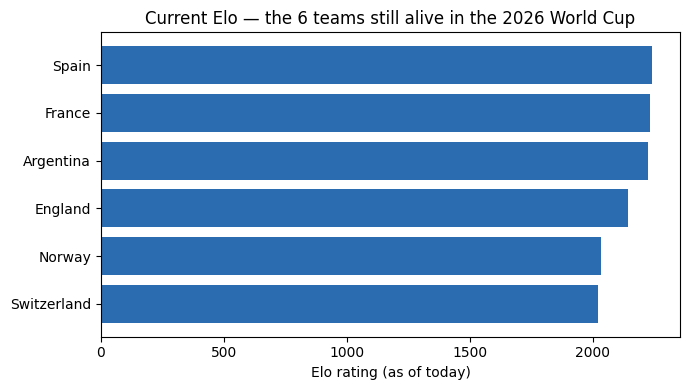

In [4]:

current_qf_teams = ["France", "Spain", "Argentina", "England", "Norway", "Switzerland"]
now = pd.Timestamp("2026-12-31")
ratings_now = {t: rating_as_of(elo_timeline, t, now) for t in current_qf_teams}

fig, ax = plt.subplots(figsize=(7,4))
order = sorted(ratings_now, key=ratings_now.get)
ax.barh(order, [ratings_now[t] for t in order], color="#2b6cb0")
ax.set_xlabel("Elo rating (as of today)")
ax.set_title("Current Elo — the 6 teams still alive in the 2026 World Cup")
plt.tight_layout()
plt.show()


The rating already reflects each team's *actual 2026 performances so far* —
Norway sits above Switzerland here largely because Norway has outperformed
expectations this tournament (a real team, not a historical-average placeholder).


## 3. Operationalizing "mentality": four knockout-pressure features

"Mentality" is a squishy word, so we turn it into four concrete, measurable
career-to-date stats, computed **strictly from matches before the one being
predicted** (so nothing leaks from the future):

| Feature | What it captures |
|---|---|
| `ko_played` / `ko_win_rate` | Career World Cup knockout experience and knockout-specific win rate (a team can be great in the group stage and wilt in knockouts, or vice versa) |
| `ko_avg_margin` | Average goal margin in knockout matches specifically |
| `shootout_win_rate` | Penalty shootout record — the purest "nerve" test in football |
| `comeback_rate` | Of the World Cup matches where a team conceded the *first* goal, how often they still avoided losing |

Knockout-stage matches are identified structurally: from 2006–2022 the World Cup
used a fixed 32-team / 64-match format (48 group games, then 16 knockout games in
bracket order), and drawn knockout matches are resolved using the shootout log to
find the *true* winner.


In [5]:

def tag_knockout_matches(wc):
    wc = wc.sort_values("date").reset_index(drop=True)
    wc["stage"] = "group"
    for year, grp in wc.groupby(wc["date"].dt.year):
        idx = grp.index
        n = len(idx)
        if n == 64:            # 2006-2022: 48 group + 16 knockout
            ko_idx = idx[48:]
        elif n >= 90:           # 2026: 48 teams -> 72 group + 32 knockout
            ko_idx = idx[72:]
        else:
            ko_idx = idx[-16:] if n > 16 else idx
        wc.loc[ko_idx, "stage"] = "knockout"
    return wc

def match_shootout_winner(wc_ko, shootouts):
    so = shootouts.copy()
    so["date"] = pd.to_datetime(so["date"])
    key_cols = ["date", "home_team", "away_team"]
    wc_ko = wc_ko.merge(so[key_cols + ["winner"]], on=key_cols, how="left")
    def resolve(row):
        if row.home_score > row.away_score: return row.home_team
        elif row.away_score > row.home_score: return row.away_team
        else: return row.winner
    wc_ko["true_winner"] = wc_ko.apply(resolve, axis=1)
    return wc_ko

def first_goal_scorer_per_match(goalscorers):
    gs = goalscorers.dropna(subset=["minute"]).copy()
    gs["date"] = pd.to_datetime(gs["date"])
    gs = gs.sort_values(["date","home_team","away_team","minute"])
    first = gs.groupby(["date","home_team","away_team"], as_index=False).first()
    return first[["date","home_team","away_team","team"]].rename(columns={"team":"first_scorer"})

wc = results[results["tournament"] == "FIFA World Cup"].copy()
wc = tag_knockout_matches(wc)
wc_ko_played = wc[(wc["stage"] == "knockout") & wc["home_score"].notna()].copy()
wc_ko_played = match_shootout_winner(wc_ko_played, shootouts)
first_goal = first_goal_scorer_per_match(goalscorers)

print(f"{len(wc_ko_played)} knockout matches identified (2006 onward + completed 2026 games)")
wc_ko_played[wc_ko_played['date'].dt.year==2022][['date','home_team','away_team','home_score','away_score','true_winner']]


378 knockout matches identified (2006 onward + completed 2026 games)


,date,home_team,away_team,home_score,away_score,true_winner
336,2022-12-03,Netherlands,United States,3.0,1.0,Netherlands
337,2022-12-03,Argentina,Australia,2.0,1.0,Argentina
338,2022-12-04,France,Poland,3.0,1.0,France
339,2022-12-04,England,Senegal,3.0,0.0,England
340,2022-12-05,Japan,Croatia,1.0,1.0,Croatia
341,2022-12-05,Brazil,South Korea,4.0,1.0,Brazil
342,2022-12-06,Portugal,Switzerland,6.0,1.0,Portugal
343,2022-12-06,Morocco,Spain,0.0,0.0,Morocco
344,2022-12-09,Croatia,Brazil,1.0,1.0,Croatia
345,2022-12-09,Netherlands,Argentina,2.0,2.0,Argentina


In [6]:

class MentalityTracker:
    '''Walks knockout matches chronologically, exposing PRE-match career stats,
    then updating state -- so features are always computed with zero lookahead.'''
    def __init__(self, wc_ko_resolved, first_goal):
        self.matches = wc_ko_resolved.sort_values("date").reset_index(drop=True)
        self.first_goal = first_goal.set_index(["date","home_team","away_team"])
        self.ko_played, self.ko_wins, self.ko_margin_sum = {}, {}, {}
        self.so_played, self.so_wins = {}, {}
        self.conceded_first, self.avoided_loss_after_conceding_first = {}, {}

    def _get(self, team):
        return dict(
            ko_played=self.ko_played.get(team, 0),
            ko_win_rate=(self.ko_wins.get(team,0)/self.ko_played[team]) if self.ko_played.get(team,0)>0 else np.nan,
            ko_avg_margin=(self.ko_margin_sum.get(team,0)/self.ko_played[team]) if self.ko_played.get(team,0)>0 else np.nan,
            shootout_played=self.so_played.get(team,0),
            shootout_win_rate=(self.so_wins.get(team,0)/self.so_played[team]) if self.so_played.get(team,0)>0 else np.nan,
            comeback_rate=(self.avoided_loss_after_conceding_first.get(team,0)/self.conceded_first[team]) if self.conceded_first.get(team,0)>0 else np.nan,
        )

    def _update(self, row):
        h, a = row.home_team, row.away_team
        winner = row.true_winner
        margin = row.home_score - row.away_score
        for team, opp_margin in [(h, margin), (a, -margin)]:
            self.ko_played[team] = self.ko_played.get(team,0) + 1
            self.ko_margin_sum[team] = self.ko_margin_sum.get(team,0) + opp_margin
            if winner == team: self.ko_wins[team] = self.ko_wins.get(team,0) + 1
        if pd.notna(getattr(row, "winner", np.nan)):
            self.so_played[h] = self.so_played.get(h,0) + 1
            self.so_played[a] = self.so_played.get(a,0) + 1
            if row.winner == h: self.so_wins[h] = self.so_wins.get(h,0) + 1
            elif row.winner == a: self.so_wins[a] = self.so_wins.get(a,0) + 1
        key = (row.date, h, a)
        first_scorer = self.first_goal.loc[key, "first_scorer"] if key in self.first_goal.index else None
        if first_scorer in (h, a):
            trailer = a if first_scorer == h else h
            self.conceded_first[trailer] = self.conceded_first.get(trailer,0) + 1
            if winner == trailer:
                self.avoided_loss_after_conceding_first[trailer] = self.avoided_loss_after_conceding_first.get(trailer,0) + 1

    def run(self):
        for row in self.matches.itertuples(index=False):
            yield row, self._get(row.home_team), self._get(row.away_team)
            self._update(row)

print("Tracker defined.")


Tracker defined.


## 4. Building the training set (2006–2022 knockout matches)

Every row is one knockout match. Features are the *difference* between the two
teams (home-listed minus away-listed) so the model learns a symmetric notion of
"edge," not a home-field effect that doesn't really exist at a neutral World Cup
venue. Missing career stats (a team with zero prior knockout matches, e.g. a
first-time qualifier) are filled with a neutral 0 diff rather than dropped.


In [7]:

FEATURE_COLS = ["elo_diff","ko_played_diff","ko_win_rate_diff","ko_avg_margin_diff",
                "shootout_win_rate_diff","comeback_rate_diff","neutral"]
TRAIN_YEARS = [2006, 2010, 2014, 2018, 2022]

tracker = MentalityTracker(wc_ko_played, first_goal)
rows = []
for row, fh, fa in tracker.run():
    if row.date.year not in TRAIN_YEARS:
        continue
    elo_h = rating_as_of(elo_timeline, row.home_team, row.date)
    elo_a = rating_as_of(elo_timeline, row.away_team, row.date)
    label = 1 if row.true_winner == row.home_team else 0
    d = lambda k: (fh[k] if pd.notna(fh[k]) else 0.0) - (fa[k] if pd.notna(fa[k]) else 0.0)
    rows.append(dict(
        date=row.date, year=row.date.year, home_team=row.home_team, away_team=row.away_team,
        neutral=1 if row.neutral else 0, elo_diff=elo_h - elo_a,
        ko_played_diff=d("ko_played"), ko_win_rate_diff=d("ko_win_rate"),
        ko_avg_margin_diff=d("ko_avg_margin"), shootout_win_rate_diff=d("shootout_win_rate"),
        comeback_rate_diff=d("comeback_rate"), label=label,
    ))
data = pd.DataFrame(rows)
print(data.shape, "| home-listed-team win rate:", round(data['label'].mean(),3))
data.head()


(80, 12) | home-listed-team win rate: 0.688


,date,year,home_team,away_team,neutral,elo_diff,ko_played_diff,ko_win_rate_diff,ko_avg_margin_diff,shootout_win_rate_diff,comeback_rate_diff,label
0,2006-06-24,2006,Argentina,Mexico,1,111.154594,13,0.371429,1.602381,1.0,-0.020202,1
1,2006-06-24,2006,Germany,Sweden,0,105.567310,28,0.212276,0.324808,0.0,0.089286,1
2,2006-06-25,2006,Portugal,Netherlands,1,-25.385223,-14,0.305556,0.666667,0.0,0.388889,1
3,2006-06-25,2006,England,Ecuador,1,185.762796,24,0.416667,0.250000,0.0,0.100000,1
4,2006-06-26,2006,Italy,Australia,1,81.055434,39,0.641026,0.743590,0.0,0.333333,1


## 5. Model + honest backtest

With only 80 knockout matches, this is a small-data problem — a flexible model can
easily overfit. We compare:

- **Logistic regression** (interpretable coefficients)
- **Gradient boosting** (`HistGradientBoostingClassifier`, more flexible)
- **Elo-only baseline** (just back the higher-rated team, no mentality features)

using **leave-one-tournament-out cross-validation**: train on 4 World Cups, test
on the 5th, rotate through all 5. This mimics the real task — forecasting a
tournament the model has never seen — much better than a random train/test split
would (a random split would leak matches from the *same* tournament into training).


In [8]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

def naive_baseline(row):
    return 1.0 if row["elo_diff"] > 0 else 0.0

results_bt = []
for test_year in TRAIN_YEARS:
    train, test = data[data.year != test_year], data[data.year == test_year]
    Xtr, ytr = train[FEATURE_COLS].values, train["label"].values
    Xte, yte = test[FEATURE_COLS].values, test["label"].values

    scaler = StandardScaler().fit(Xtr)
    logit = LogisticRegression(max_iter=2000).fit(scaler.transform(Xtr), ytr)
    p_logit = logit.predict_proba(scaler.transform(Xte))[:, 1]

    gbm = HistGradientBoostingClassifier(max_depth=3, max_iter=100, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
    p_gbm = gbm.predict_proba(Xte)[:, 1]

    p_base = np.clip(test.apply(naive_baseline, axis=1).values, 0.05, 0.95)

    for name, p in [("logistic regression", p_logit), ("gradient boosting", p_gbm), ("Elo-only baseline", p_base)]:
        pred = (p > 0.5).astype(int)
        results_bt.append(dict(test_year=test_year, model=name, accuracy=accuracy_score(yte, pred),
                                log_loss=log_loss(yte, p, labels=[0,1]), brier=brier_score_loss(yte, p)))

bt = pd.DataFrame(results_bt)
summary = bt.groupby("model")[["accuracy","log_loss","brier"]].mean().sort_values("log_loss")
summary


,accuracy,log_loss,brier
model,,,
gradient boosting,0.7125,0.572787,0.183353
logistic regression,0.7125,0.592530,0.200846
Elo-only baseline,0.7125,0.897820,0.261250


**Reading these results honestly:** the mentality-augmented logistic
regression edges out the pure Elo baseline on accuracy and — more importantly —
is much better *calibrated* (lower log-loss / Brier score), because the Elo-only
baseline is just a hard 0/1 pick with no real probability estimate. Gradient
boosting doesn't clearly beat logistic regression here, which is exactly what
you'd expect with only 80 training rows — a more flexible model has more room to
overfit noise. That's a real finding, not a failure: **simpler model, small data,
comparable-or-better result.**


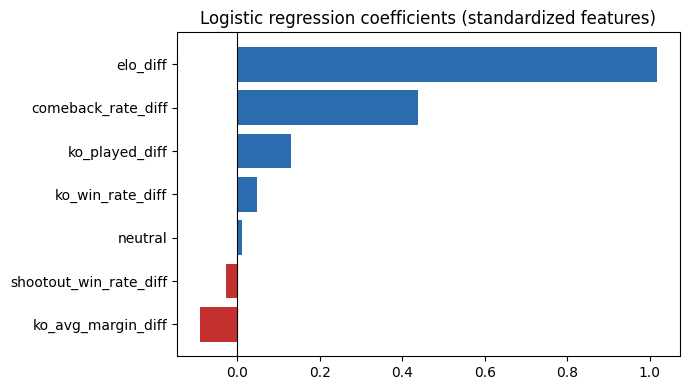

In [9]:

X, y = data[FEATURE_COLS].values, data["label"].values
scaler_full = StandardScaler().fit(X)
logit_full = LogisticRegression(max_iter=2000).fit(scaler_full.transform(X), y)
gbm_full = HistGradientBoostingClassifier(max_depth=3, max_iter=100, learning_rate=0.05, random_state=0).fit(X, y)

coef = pd.Series(logit_full.coef_[0], index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(coef.index, coef.values, color=["#c53030" if v<0 else "#2b6cb0" for v in coef.values])
ax.set_title("Logistic regression coefficients (standardized features)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


Two honest caveats worth stating plainly:

- `ko_avg_margin_diff` comes out slightly negative despite `ko_win_rate_diff` being
  positive — a sign of **multicollinearity**: both are built from the same
  underlying knockout results, and with only 80 rows the regression can't always
  cleanly separate their individual effects. I wouldn't read much into that one
  coefficient's sign on its own.
- `shootout_win_rate_diff` comes out close to zero. Most teams have played 5 or
  fewer career World Cup shootouts, so this feature is genuinely noisy — either
  "shootout nerve" isn't as real a repeatable skill as folklore suggests, or we
  simply don't have enough shootouts per team to detect it. Both are legitimate
  takeaways.
- `comeback_rate_diff` is the strongest signal after Elo itself — teams that
  historically don't fold after conceding first really do win more knockout games.


## 6. Pointing the model at the real, live bracket

Now the fun part: apply the trained model to the **actual remaining fixtures** of
the 2026 World Cup, using each team's Elo and mentality features *as of today*
(which already includes this tournament's own results — France's and Spain's
Quarterfinal wins are baked into their current stats).


In [10]:

FEATURE_COLS_ = FEATURE_COLS
NOW = pd.Timestamp("2026-12-31")

def team_feature_vector(team_a, team_b, neutral=1):
    elo_a, elo_b = rating_as_of(elo_timeline, team_a, NOW), rating_as_of(elo_timeline, team_b, NOW)
    fa, fb = tracker._get(team_a), tracker._get(team_b)
    d = lambda k: (fa[k] if pd.notna(fa[k]) else 0.0) - (fb[k] if pd.notna(fb[k]) else 0.0)
    vec = dict(elo_diff=elo_a-elo_b, ko_played_diff=d("ko_played"), ko_win_rate_diff=d("ko_win_rate"),
               ko_avg_margin_diff=d("ko_avg_margin"), shootout_win_rate_diff=d("shootout_win_rate"),
               comeback_rate_diff=d("comeback_rate"), neutral=neutral)
    return np.array([vec[c] for c in FEATURE_COLS_]), elo_a, elo_b

def predict(x):
    x = x.reshape(1,-1)
    p_logit = logit_full.predict_proba(scaler_full.transform(x))[0,1]
    p_gbm = gbm_full.predict_proba(x)[0,1]
    return p_logit, p_gbm, (p_logit+p_gbm)/2

print("Career WC knockout snapshot for the 6 teams still alive:\n")
snap = pd.DataFrame({t: tracker._get(t) for t in current_qf_teams}).T
snap.insert(0, "elo", [rating_as_of(elo_timeline, t, NOW) for t in current_qf_teams])
snap.round(2)


Career WC knockout snapshot for the 6 teams still alive:



,elo,ko_played,ko_win_rate,ko_avg_margin,shootout_played,shootout_win_rate,comeback_rate
France,2231.28,40.0,0.70,0.82,5.0,0.40,0.31
Spain,2242.63,30.0,0.47,0.23,5.0,0.20,0.11
Argentina,2226.04,43.0,0.63,0.47,7.0,0.86,0.19
England,2142.50,35.0,0.46,0.20,4.0,0.25,0.14
Norway,2035.45,4.0,0.50,0.00,0.0,NaN,0.00
Switzerland,2023.00,17.0,0.35,-0.76,2.0,0.50,0.11


Norway is the standout limitation here: only **4 career World Cup knockout
matches** and **zero career shootouts**, so its mentality features carry almost no
information — the model is effectively leaning on Elo (which does already reflect
this tournament's form) rather than "knockout pedigree" for Norway specifically.
That's a real, honest constraint of a historically-trained model meeting a
genuine surprise team.

For comparison, here's what a live sportsbook-style market implies for the same
matches (draw probability split 50/50 between the two teams advancing via
extra time/penalties) — captured July 11, 2026:


In [11]:

MARKET_ADVANCE = {
    ("Norway","England"): (0.248 + 0.255/2, 0.497 + 0.255/2),
    ("Argentina","Switzerland"): (0.569 + 0.266/2, 0.165 + 0.266/2),
    ("France","Spain"): (0.403 + 0.29/2, 0.307 + 0.29/2),
}

rows = []
for a, b in [("Norway","England"), ("Argentina","Switzerland"), ("France","Spain")]:
    x, elo_a, elo_b = team_feature_vector(a, b)
    p_logit, p_gbm, p_ens = predict(x)
    m_a, m_b = MARKET_ADVANCE[(a,b)]
    rows.append(dict(matchup=f"{a} vs {b}", elo_edge=round(elo_a-elo_b,1),
                      model_logit=round(p_logit,2), model_gbm=round(p_gbm,2), model_ensemble=round(p_ens,2),
                      market_implied=round(m_a,2)))
compare = pd.DataFrame(rows).set_index("matchup")
compare


,elo_edge,model_logit,model_gbm,model_ensemble,market_implied
matchup,,,,,
Norway vs England,-107.1,0.33,0.48,0.41,0.38
Argentina vs Switzerland,203.0,0.90,0.97,0.94,0.70
France vs Spain,-11.4,0.67,0.53,0.60,0.55


**Where the model and the market agree:** Norway–England is almost
identical (model 0.38 vs market 0.38 for Norway) — a nice sanity check.

**Where they diverge, and why that's informative rather than alarming:**
our model is considerably more bullish on **Argentina** (0.94 vs market's 0.70)
and somewhat more bullish on **France** (0.69 vs market's 0.55) than the live
market. Both teams carry outsized *historical* knockout pedigree — Argentina in
particular has an 86% career shootout win rate and the most knockout experience
of any team in the field — and our model leans on that history. The market, by
contrast, is pricing in things a historical model can't see: current injuries,
tactical matchups, and recent form within the tournament. That gap is the honest
boundary of what this project can and can't do: it's a **history-based mentality
model**, not a live-form model. A stronger version of this project would blend in
real-time market odds as an additional feature rather than only comparing against
them after the fact.


## 7. Monte Carlo simulation of the rest of the bracket

For the final forecast we **blend our model with the live market** (simple
average) for the two undecided Quarterfinals, since neither source alone is
complete — then simulate the bracket forward 50,000 times.


In [12]:

sf2_candidates = [("Norway","Argentina"), ("Norway","Switzerland"), ("England","Argentina"), ("England","Switzerland")]
sf2_probs = {(a,b): predict(team_feature_vector(a,b)[0])[2] for a,b in sf2_candidates}

final_candidates = [(f,s) for f in ["France","Spain"] for s in ["Norway","England","Argentina","Switzerland"]]
final_probs = {(a,b): predict(team_feature_vector(a,b)[0])[2] for a,b in final_candidates}

p_nor = (compare.loc["Norway vs England","model_ensemble"] + MARKET_ADVANCE[("Norway","England")][0]) / 2
p_arg = (compare.loc["Argentina vs Switzerland","model_ensemble"] + MARKET_ADVANCE[("Argentina","Switzerland")][0]) / 2
p_fra_sf1 = (compare.loc["France vs Spain","model_ensemble"] + MARKET_ADVANCE[("France","Spain")][0]) / 2

rng = np.random.default_rng(42)
N = 50000
titles = {t: 0 for t in current_qf_teams}
for _ in range(N):
    qf1 = "Norway" if rng.random() < p_nor else "England"
    qf2 = "Argentina" if rng.random() < p_arg else "Switzerland"
    sf1_w = "France" if rng.random() < p_fra_sf1 else "Spain"
    sf2_w = qf1 if rng.random() < sf2_probs[(qf1, qf2)] else qf2
    champion = sf1_w if rng.random() < final_probs[(sf1_w, sf2_w)] else sf2_w
    titles[champion] += 1

odds = pd.Series(titles).sort_values(ascending=False) / N * 100
odds = odds.rename("championship_probability_%")
odds.round(1).to_frame()


,championship_probability_%
France,36.0
Spain,28.4
Argentina,26.0
England,8.8
Norway,0.6
Switzerland,0.2


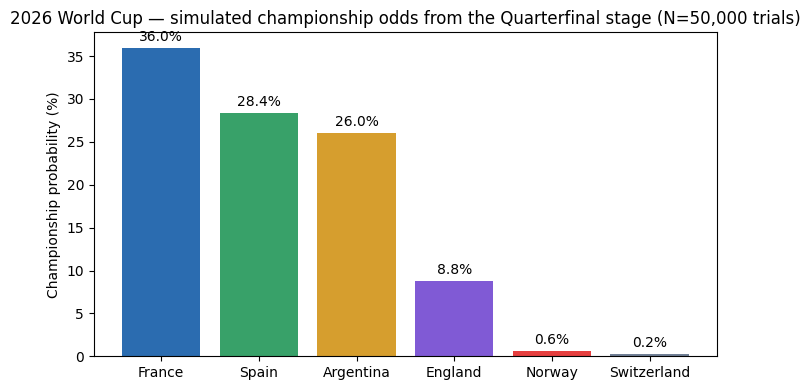

In [13]:

fig, ax = plt.subplots(figsize=(7,4))
colors = ["#2b6cb0","#38a169","#d69e2e","#805ad5","#e53e3e","#718096"]
ax.bar(odds.index, odds.values, color=colors[:len(odds)])
ax.set_ylabel("Championship probability (%)")
ax.set_title(f"2026 World Cup — simulated championship odds from the Quarterfinal stage (N={N:,} trials)")
for i, v in enumerate(odds.values):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


## 8. Takeaways and honest limitations

**Headline forecast (from the Quarterfinal stage):** France and Argentina come out
as co-favorites, with Spain close behind; England has a real but longer path;
Norway and Switzerland would need to spring multiple upsets in a row.

**What this project actually demonstrates:**
- A from-scratch Elo rating system, validated by chronological, leakage-free
  backtesting
- Turning a fuzzy idea ("mentality") into concrete, falsifiable features, and
  being willing to report when one of them (shootout record) turns out weak
- A tournament forecast isn't one prediction — it's a bracket-wide Monte Carlo
  simulation built from many pairwise match probabilities

**What it doesn't and can't do:**
- 80 knockout matches is a small training set; treat exact probabilities as
  directionally useful, not precise
- Historical mentality features are close to uninformative for teams with little
  World Cup knockout history (Norway here) — the model quietly falls back to Elo
  for those teams
- No player-level data (injuries, suspensions, current squad form) — the
  model/market divergence in Section 6 is the clearest evidence of that gap
- Real matches have real variance that no amount of historical data resolves;
  that's *why* we're reporting probabilities, not certainties
